In [3]:
import pandas as pd
import numpy as np 
import spacy
from spacy import displacy
import networkx as nx

import matplotlib.pyplot as plt

In [4]:
!python3 -m spacy download en_core_web_sm

/Users/phinhasasmelash/Projects/witcher_character_analysis/witcher_venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 89.0 MB/s  0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [12]:
# Load spacy English language model
# Named Entity Recognition
NER = spacy.load("en_core_web_sm")

## Load Books

In [5]:
import os

# Get all book files in the data directory
all_books = [b for b in os.scandir('data') if '.txt' in b.name]

In [10]:
all_books[7]

<DirEntry 'III - Baptism of Fire.txt'>

In [19]:
book = all_books[1] 
book_text = open(book).read()
book_doc = NER(book_text)

In [20]:
# Visualize identified entities
displacy.render(book_doc[0:2000], style="ent", jupyter=True) 

## Load Character names

In [22]:
# read characters 
character_df = pd.read_csv("characters.csv")

In [23]:
# remove brackets and text within brackets 
import re
character_df['character'] = character_df['character'].apply(
    lambda x: re.sub("\(].*?[\)]", "", x)
)

character_df['character_firstname'] = character_df['character'].apply(
    lambda x: x.split(' ', 1)[0]
)

In [24]:
pd.set_option('display.max_rows', None)
character_df

,book,character,character_firstname
0,Category:Baptism of Fire characters,Adalia,Adalia
1,Category:Baptism of Fire characters,Adela,Adela
2,Category:Baptism of Fire characters,Aen Saevherne,Aen
3,Category:Baptism of Fire characters,Aevenien,Aevenien
4,Category:Baptism of Fire characters,Aglaïs,Aglaïs
5,Category:Baptism of Fire characters,Albrich,Albrich
6,Category:Baptism of Fire characters,Amavet,Amavet
7,Category:Baptism of Fire characters,Angus Bri Cri,Angus
8,Category:Baptism of Fire characters,Anna Kameny,Anna
9,Category:Baptism of Fire characters,Anzelm Aubry,Anzelm


## get named entity list per sentence

In [25]:
sent_entity_df = []

# loop thru sentences, store named entity list for each sentence
for sent in book_doc.sents:
    entity_list = [ent.text for ent in sent.ents]
    sent_entity_df.append({"sentence": sent, "entities": entity_list})

sent_entity_df = pd.DataFrame(sent_entity_df)

In [26]:
sent_entity_df

,sentence,entities
0,"(﻿The, Limits, of, the, Possible, \n, I, \n, ""...",[]
1,"("", It, 's, been, an, hour, and, a, quarter, s...",[an hour and a quarter]
2,"(He, 's, done, for, .)",[]
3,"("", \n, The, townsfolk, ,, huddled, together, ...",[]
4,"(A, fat, man, dressed, in, a, yellow, smock, \...",[one foot]
5,"("", We, have, to, wait, a, bit, longer, ,, "", ...",[]
6,"("", Why, wait, ?, "", snorted, pimply, ,, "", Th...",[]
7,"(Anyone, goes, down, there, ,, that, 's, the, ...",[]
8,"(Have, you, forgotten, how, many, \n, have, di...",[]
9,"(What, are, we, waiting, for, ?, "", \n, "", Thi...",[]


In [27]:
# function to filter out non-character entities
def filter_entity(ent_list, character_df):
    return [ent for ent in ent_list
            if ent in list(character_df.character) 
            or ent in list(character_df.character_firstname)]

In [34]:
filter_entity(["Geralt of Rivia", "Thu", "2"], character_df)

['Geralt of Rivia']

In [36]:
sent_entity_df['character_entities'] = sent_entity_df['entities'].apply(lambda x: filter_entity(x, character_df))
# filter out sentences that don't have any character entities
sent_entity_df_filtered = sent_entity_df[sent_entity_df['character_entities'].map(len) > 0]
sent_entity_df_filtered.head(20)

,sentence,entities,character_entities
94,"(Is, there, anything, keeping, you, in, this, ...",[Geralt of Rivia],[Geralt of Rivia]
100,"(It, would, be, an, honour, if, you, would, ac...",[Geralt],[Geralt]
104,"("", \n, "", There, are, some, ,, "", Geralt, rep...",[Geralt],[Geralt]
108,"("", \n, Geralt, took, off, a, glove, and, shoo...",[Geralt],[Geralt]
136,"("", I, forgot, ,, "", Three, Jackdaws, winked, ...","[Three Jackdaws, Geralt]",[Geralt]
147,"(Geralt, loosened, his, belt, ,, removed, his,...",[Geralt],[Geralt]
152,"("", Do, the, girls, speak, the, common, langua...",[Geralt],[Geralt]
155,"(How, 's, your, soup, ,, Geralt, ?, "", \n, "", ...",[Geralt],[Geralt]
162,"(Yet, there, is, a, certain, principal, underl...",[Geralt],[Geralt]
189,"(Let, 's, say, a, fierce, dragon, destroys, .....",[Geralt],[Geralt]


In [39]:
# take only first name of characters
sent_entity_df_filtered['character_entities'] = sent_entity_df_filtered['character_entities'].apply(
    lambda x: [item.split()[0] for item in x])

/var/folders/xj/923x202d1pb1kp5zbcc08fvr0000gn/T/ipykernel_18490/2191957376.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sent_entity_df_filtered['character_entities'] = sent_entity_df_filtered['character_entities'].apply(


In [41]:
pd.reset_option('^display', silent=True)
sent_entity_df_filtered

,sentence,entities,character_entities
94,"(Is, there, anything, keeping, you, in, this, ...",[Geralt of Rivia],[Geralt]
100,"(It, would, be, an, honour, if, you, would, ac...",[Geralt],[Geralt]
104,"("", \n, "", There, are, some, ,, "", Geralt, rep...",[Geralt],[Geralt]
108,"("", \n, Geralt, took, off, a, glove, and, shoo...",[Geralt],[Geralt]
136,"("", I, forgot, ,, "", Three, Jackdaws, winked, ...","[Three Jackdaws, Geralt]",[Geralt]
...,...,...,...
11031,"(Yurga, did, n't, see, Geralt, 's, face, ,, hi...","[Yurga, Geralt]","[Yurga, Geralt]"
11032,"(He, only, saw, black, -, gloved, hands, squee...",[Ciri],[Ciri]
11034,"(Oh, ,, Geralt, !)",[Geralt],[Geralt]
11039,"(Say, it, ,, Geralt, !)",[Geralt],[Geralt]


## Create relationships

In [57]:
window_size = 5
relationships = []
# perform a rolling window through the text to identify characters within the same window
for i in range(sent_entity_df_filtered.index[-1]):
    end_i = min(i+5, sent_entity_df_filtered.index[-1])
    # trick: if you add a 2D list to an empty list using the sum() func it returns a 1D list
    char_list = sum((sent_entity_df_filtered.loc[i: end_i].character_entities), [])

    
    # remove duplicated characters that are next to each other
    char_unique = [char_list[i] for i in range(len(char_list))
                    if (i==0) or char_list[i] != char_list[i-1]] 
    if len(char_unique) > 1:
        for idx, a in enumerate(char_unique[:-1]):
            b = char_unique[idx + 1]
            relationships.append({"source": a, "target": b}) 

In [58]:
relationship_df = pd.DataFrame(relationships)

In [59]:
pd.set_option('display.max_rows', None)
relationship_df
# relationship_df.to_csv('relationship.csv', index=False)


,source,target
0,Geralt,Niedamir
1,Geralt,Niedamir
2,Geralt,Niedamir
3,Niedamir,Geralt
4,Niedamir,Geralt
5,Geralt,Niedamir
6,Geralt,Niedamir
7,Niedamir,Geralt
8,Niedamir,Geralt
9,Niedamir,Geralt


In [61]:
# sort the cases with a->b and b->a

relationship_df = pd.DataFrame(np.sort(relationship_df.values, axis = 1), columns = relationship_df.columns)

relationship_df

,source,target
0,Geralt,Niedamir
1,Geralt,Niedamir
2,Geralt,Niedamir
3,Geralt,Niedamir
4,Geralt,Niedamir
5,Geralt,Niedamir
6,Geralt,Niedamir
7,Geralt,Niedamir
8,Geralt,Niedamir
9,Geralt,Niedamir


In [62]:
relationship_df["value"] = 1
relationship_df = relationship_df.groupby(["source", "target"], sort=False, as_index=False).sum()

In [64]:
relationship_df.head(20)

,source,target,value
0,Geralt,Niedamir,48
1,Eyck,Geralt,41
2,Dorregaray,Geralt,68
3,Dorregaray,Yennefer,97
4,Boholt,Niedamir,37
5,Geralt,Yarpen,23
6,Geralt,Gyllenstiern,35
7,Boholt,Geralt,80
8,Geralt,Kennet,2
9,Boholt,Kennet,12


## Graph analysis and visualization

In [65]:
# create a graph from a pandas dataframe
G = nx.from_pandas_edgelist(relationship_df, 
                           source = "source", 
                           target = "target", 
                           edge_attr = "value", 
                           create_using = nx.Graph())

### Graph visualization - Networkx

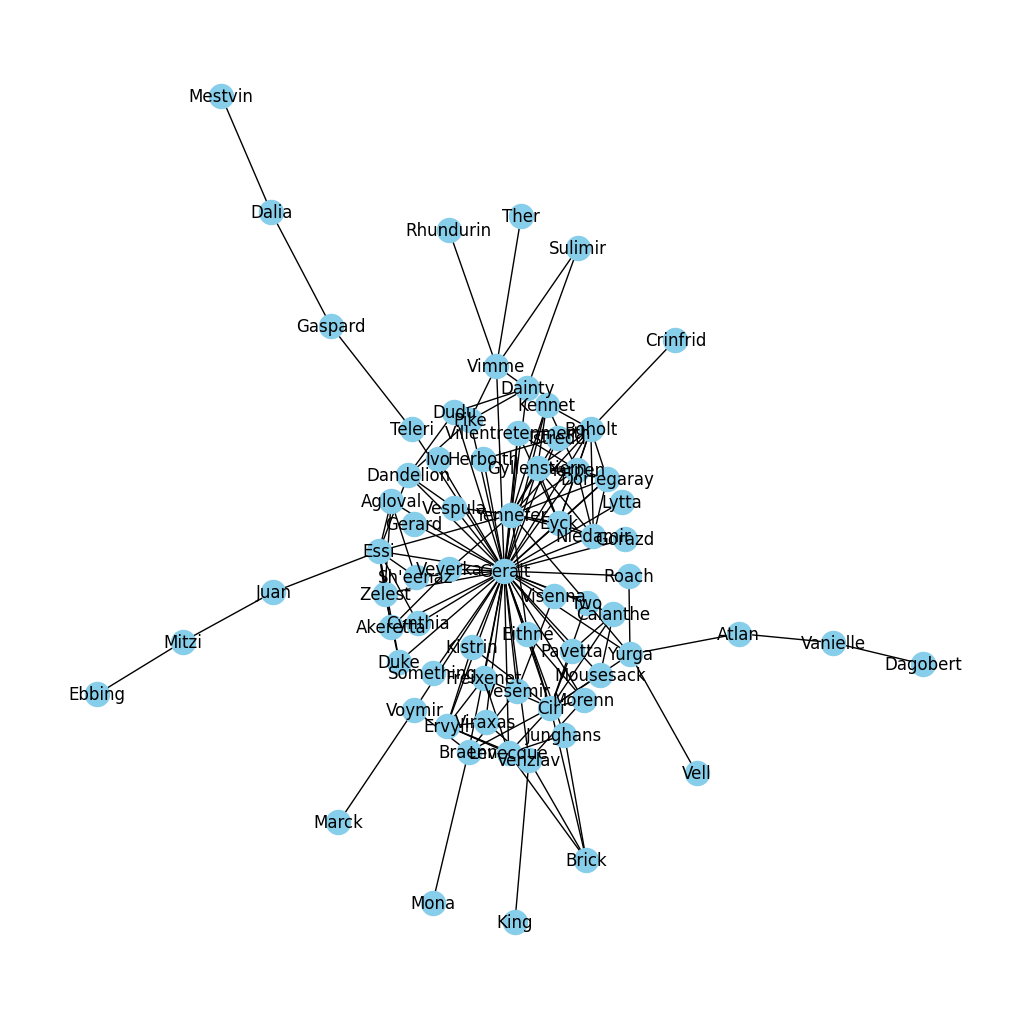

In [67]:
plt.figure(figsize=(10,10))
pos = nx.kamada_kawai_layout(G)
nx.draw(G, with_labels=True, node_color='skyblue', edge_cmap=plt.cm.Blues, pos = pos)
plt.show()

## Graph visualization - Pyvis

In [78]:
from pyvis.network import Network
 
net = Network(notebook=True, width="1000px", height="800px", bgcolor='#222222', font_color='white')

node_degree = dict(G.degree)

# Setting up node size attribute
nx.set_node_attributes(G, node_degree, 'size')

net.from_nx(G) 
net.show("witcher.html")

witcher.html


## The most important characters in the Witcher (based on centrality measures)

In [79]:
# Degree centrality (Aka highest number of edges)
degree_dict = nx.degree_centrality(G)
degree_dict

{'Geralt': 0.7391304347826088,
 'Niedamir': 0.10144927536231885,
 'Eyck': 0.11594202898550725,
 'Dorregaray': 0.10144927536231885,
 'Yennefer': 0.21739130434782608,
 'Boholt': 0.14492753623188406,
 'Yarpen': 0.13043478260869565,
 'Gyllenstiern': 0.11594202898550725,
 'Kennet': 0.07246376811594203,
 'Crinfrid': 0.014492753623188406,
 'Villentretenmerth': 0.07246376811594203,
 'Istredd': 0.043478260869565216,
 'Herbolth': 0.028985507246376812,
 'Ivo': 0.014492753623188406,
 'Two': 0.057971014492753624,
 'Vespula': 0.043478260869565216,
 'Dainty': 0.07246376811594203,
 'Dandelion': 0.07246376811594203,
 'Pike': 0.057971014492753624,
 'Vimme': 0.08695652173913043,
 'Sulimir': 0.028985507246376812,
 'Ther': 0.014492753623188406,
 'Rhundurin': 0.014492753623188406,
 'Dudu': 0.043478260869565216,
 "Sh'eenaz": 0.043478260869565216,
 'Agloval': 0.057971014492753624,
 'Teleri': 0.028985507246376812,
 'Gaspard': 0.028985507246376812,
 'Dalia': 0.028985507246376812,
 'Mestvin': 0.01449275362318840

<Axes: >

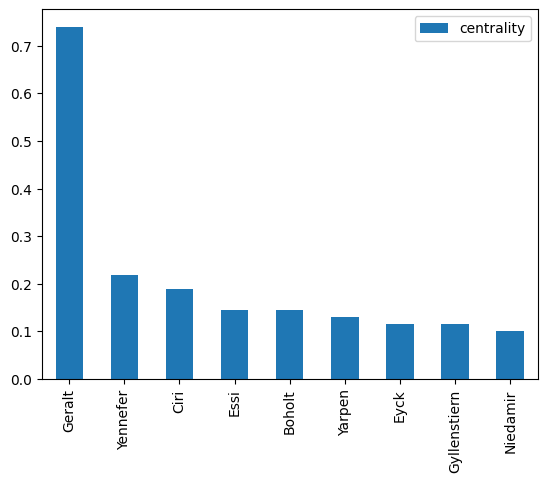

In [72]:
degree_df = pd.DataFrame.from_dict(degree_dict, orient='index', columns=['centrality'])
# plot top 10 nodes
degree_df.sort_values('centrality', ascending=False)[0:9].plot(kind="bar")

<Axes: >

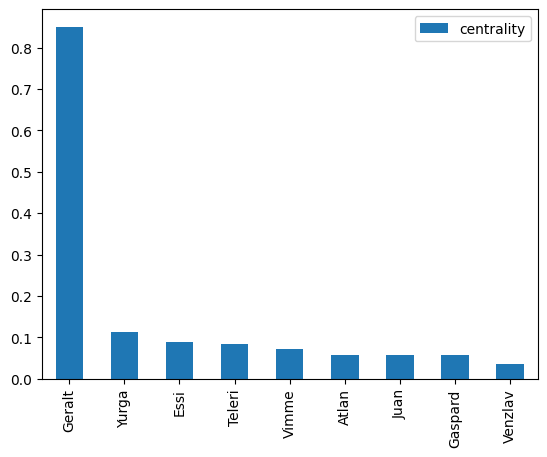

In [80]:
# Betweenness centrality. quantifies number of short paths that go thru a node (Aka that friend that introduces you to other ppl)
betweenness_dict = nx.betweenness_centrality(G)
betweenness_dict = pd.DataFrame.from_dict(betweenness_dict, orient='index', columns=['centrality'])
# plot top 10 nodes
betweenness_dict.sort_values('centrality', ascending=False)[0:9].plot(kind="bar")

<Axes: >

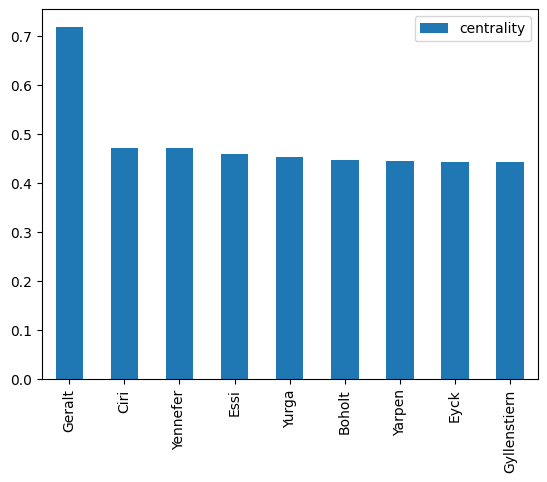

In [81]:
# closeness centrality. quantifies how close a node is to all other nodes (aka good for spreading information)
closeness_dict = nx.closeness_centrality(G)
closeness_dict = pd.DataFrame.from_dict(closeness_dict, orient='index', columns=['centrality'])
# plot top 10 nodes
closeness_dict.sort_values('centrality', ascending=False)[0:9].plot(kind="bar")

In [82]:
# save centrality measures
nx.set_node_attributes(G, degree_dict, 'degree_centrality')
nx.set_node_attributes(G, betweenness_dict, 'betweenness_centrality')
nx.set_node_attributes(G, closeness_dict, 'closeness_centrality')


### Community Detection

In [84]:
import community as community_louvain

In [85]:
communities = community_louvain.best_partition(G)

In [86]:
communities

{'Geralt': 0,
 'Niedamir': 1,
 'Eyck': 1,
 'Dorregaray': 1,
 'Yennefer': 1,
 'Boholt': 1,
 'Yarpen': 1,
 'Gyllenstiern': 1,
 'Kennet': 1,
 'Crinfrid': 1,
 'Villentretenmerth': 1,
 'Istredd': 0,
 'Herbolth': 0,
 'Ivo': 0,
 'Two': 2,
 'Vespula': 3,
 'Dainty': 3,
 'Dandelion': 3,
 'Pike': 3,
 'Vimme': 3,
 'Sulimir': 3,
 'Ther': 3,
 'Rhundurin': 3,
 'Dudu': 3,
 "Sh'eenaz": 0,
 'Agloval': 0,
 'Teleri': 4,
 'Gaspard': 4,
 'Dalia': 4,
 'Mestvin': 4,
 'Essi': 0,
 'Gerard': 0,
 'Zelest': 0,
 'Duke': 0,
 'Veverka': 0,
 'Akeretta': 0,
 'Something': 0,
 'Ebbing': 5,
 'Mitzi': 5,
 'Juan': 5,
 'Cynthia': 0,
 'Braenn': 6,
 'Ciri': 7,
 'Freixenet': 7,
 'Marck': 6,
 'Voymir': 6,
 'Kistrin': 7,
 'Vesemir': 6,
 'Ervyll': 7,
 'Eithné': 7,
 'Venzlav': 7,
 'Viraxas': 7,
 'Morenn': 7,
 'Mona': 6,
 'Pavetta': 7,
 'Brick': 7,
 'Junghans': 7,
 'Levecque': 7,
 'King': 7,
 'Mousesack': 7,
 'Calanthe': 7,
 'Yurga': 2,
 'Roach': 2,
 'Vell': 2,
 'Visenna': 6,
 'Atlan': 2,
 'Vanielle': 2,
 'Dagobert': 2,
 'Lytta': 0,

In [87]:
nx.set_node_attributes(G, communities, 'group')

In [89]:
comm_net = Network(notebook=True, width='1000px', height='800px', bgcolor='#222222', font_color='white')
comm_net.from_nx(G)
comm_net.show("witcher_communities.html")

witcher_communities.html
